# Top-K Feature Selection Ablation Study

This notebook analyzes how different top-k feature selection thresholds (k ∈ {0.125, 0.250, 0.375, 0.500}) affect explanation stability across models and methods.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from notebook_utils import bootstrap_mean_and_ci

## Data Loading Functions

In [2]:
def prepend_ones(arr):
    """Prepend column of ones to array for radius=0 stability"""
    ones = np.ones((arr.shape[0], 1))
    return np.hstack((ones, arr))

def load_vision_method_soft_topk(model, method, top_k_str):
    """Load soft stability rates for vision model/method at specific top-k threshold"""
    if top_k_str == "0.250":
        # Default case - original files have no suffix
        filename = f"../scripts/_cache/soft_rates_{method}_{model}_imagenet_2_per_class.json"
    else:
        # Ablation case - files have top-k suffix
        filename = f"../scripts/_cache/soft_rates_{method}_{model}_imagenet_2_per_class_top{top_k_str}.json"
    
    with open(filename) as f:
        data = json.load(f)
        return prepend_ones(np.array(data["soft_stability_rates"]))

def right_last_padded(lists):
    """Right-pad lists to same length using last value, handle empty lists as completely unstable"""
    if not lists:  # Handle case where lists is empty
        return np.array([])
    
    # Filter out empty lists and track their indices
    non_empty_lists = []
    empty_indices = []
    
    for i, ls in enumerate(lists):
        if len(ls) == 0:
            empty_indices.append(i)
        else:
            non_empty_lists.append(ls)
    
    if not non_empty_lists:  # All lists are empty
        # Return array of zeros with reasonable default length
        default_length = 20  # Common radius length for text data
        return np.zeros((len(lists), default_length))
    
    # Get max length from non-empty lists
    max_len = max(len(ls) for ls in non_empty_lists)
    
    # Pad all lists
    padded_lists = []
    for i, ls in enumerate(lists):
        if i in empty_indices:
            # Empty list = completely unstable = all zeros
            padded_lists.append([0.0] * max_len)
        else:
            # Normal padding with last value
            padded_lists.append(ls + [ls[-1]] * (max_len - len(ls)))
    
    return np.array(padded_lists)

def load_roberta_method_soft_topk(method, top_k_str):
    """Load aggregated RoBERTa soft stability rates across all TweetEval tasks"""
    tasks = ["emoji", "emotion", "hate", "irony", "offensive", "sentiment"]
    all_task_data = []
    
    for task in tasks:
        if top_k_str == "0.250":
            filename = f"../scripts/_cache/soft_rates_{method}_roberta_tweeteval_{task}.json"
        else:
            filename = f"../scripts/_cache/soft_rates_{method}_roberta_tweeteval_{task}_top{top_k_str}.json"
        
        with open(filename) as f:
            task_data = json.load(f)["soft_stability_rates"]
            # Fixed: Pass task_data directly to right_last_padded, now handles empty lists
            all_task_data.append(right_last_padded(task_data))
    
    # Aggregate across tasks
    aggregated_data = np.vstack(all_task_data)
    return prepend_ones(aggregated_data)

## Load All Data with Explicit Variable Names

Using flat data structure with explicit variable naming: `{model}_{method}_soft_rates_top_{k}`

In [3]:
# Define constants following the plan
MODELS = ["vit", "resnet50", "resnet18", "roberta"]
METHODS = ["lime", "shap", "intgrad", "mfaba", "random"] 
TOPK_VALUES = ["0.125", "0.250", "0.375", "0.500"]
ROBERTA_TASKS = ["emoji", "emotion", "hate", "irony", "offensive", "sentiment"]
IMAGE_RADII = list(range(0,21)) + [30, 40, 50, 60, 70, 80, 90, 100]
TEXT_RADII = list(range(21))

print("Loading ALL data using nested loops (creates 80 variables automatically)...")
var_count = 0

for model in MODELS:
    for method in METHODS:
        for topk_str in TOPK_VALUES:
            # Create variable name: remove dots from topk_str
            var_name = f"{model}_{method}_soft_rates_top_{topk_str.replace('.', '')}"
            
            # Load data using appropriate function
            if model == "roberta":
                data = load_roberta_method_soft_topk(method, topk_str)
            else:
                data = load_vision_method_soft_topk(model, method, topk_str)
            
            # Store in global namespace  
            globals()[var_name] = data
            var_count += 1
            print(f"[{var_count}/80] Loaded {var_name}: {data.shape}")

print(f"\nSUCCESS: Loaded exactly {var_count} variables!")

Loading ALL data using nested loops (creates 80 variables automatically)...
[1/80] Loaded vit_lime_soft_rates_top_0125: (2000, 29)
[2/80] Loaded vit_lime_soft_rates_top_0250: (2000, 29)
[3/80] Loaded vit_lime_soft_rates_top_0375: (2000, 29)
[4/80] Loaded vit_lime_soft_rates_top_0500: (2000, 29)
[5/80] Loaded vit_shap_soft_rates_top_0125: (2000, 29)
[6/80] Loaded vit_shap_soft_rates_top_0250: (2000, 29)
[7/80] Loaded vit_shap_soft_rates_top_0375: (2000, 29)
[8/80] Loaded vit_shap_soft_rates_top_0500: (2000, 29)
[9/80] Loaded vit_intgrad_soft_rates_top_0125: (2000, 29)
[10/80] Loaded vit_intgrad_soft_rates_top_0250: (2000, 29)
[11/80] Loaded vit_intgrad_soft_rates_top_0375: (2000, 29)
[12/80] Loaded vit_intgrad_soft_rates_top_0500: (2000, 29)
[13/80] Loaded vit_mfaba_soft_rates_top_0125: (2000, 29)
[14/80] Loaded vit_mfaba_soft_rates_top_0250: (2000, 29)
[15/80] Loaded vit_mfaba_soft_rates_top_0375: (2000, 29)
[16/80] Loaded vit_mfaba_soft_rates_top_0500: (2000, 29)
[17/80] Loaded vit_ra

## Visualization Functions

In [4]:
def plot_methods_comparison_fixed_topk(model, topk_str, radii, output_path, **method_rates):
    """Plot all methods for a model at fixed top-k threshold"""
    fig, ax = plt.subplots(figsize=(4,3))
    fs = 14
    
    method_names = ['LIME', 'SHAP', 'IntGrad', 'MFABA', 'Random']
    
    # Model name mapping for consistent capitalization
    model_display_names = {
        'vit': 'ViT',
        'resnet18': 'ResNet18', 
        'resnet50': 'ResNet50',
        'roberta': 'RoBERTa'
    }
    
    for i, (method_key, rates) in enumerate(method_rates.items()):
        mean, lb, ub = bootstrap_mean_and_ci(rates)
        method_name = method_names[i] if i < len(method_names) else method_key
        ax.plot(radii, mean, label=method_name)
        ax.fill_between(radii, lb, ub, alpha=0.2)
    
    # Convert string to percentage for display: "0.250" -> "25.0%"
    topk_percent = float(topk_str) * 100
    model_display = model_display_names.get(model, model.upper())
    ax.set_xlabel(f"({model_display}, Top {topk_percent:.1f}%) Pert Radius", fontsize=fs)
    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.legend(fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)
    
    fig.savefig(output_path, bbox_inches="tight")
    
    # For top-k 25%, also generate a version without the percentage in the label
    if topk_str == "0.250":
        ax.set_xlabel(f"({model_display}) Pert Radius", fontsize=fs)
        # Create new filename without the top-k suffix
        base_output_path = output_path.replace("_top_0250.pdf", "_main.pdf")
        fig.savefig(base_output_path, bbox_inches="tight")
    
    return fig

## Analysis Functions

In [5]:
def analyze_topk_sensitivity(rates_0125, rates_0250, rates_0375, rates_0500, radius_idx=2):
    """Find optimal top-k value for one model/method combination"""
    # Get mean stability at radius_idx (default=2) for each top-k  
    mean_0125, _, _ = bootstrap_mean_and_ci(rates_0125)
    mean_0250, _, _ = bootstrap_mean_and_ci(rates_0250)
    mean_0375, _, _ = bootstrap_mean_and_ci(rates_0375)
    mean_0500, _, _ = bootstrap_mean_and_ci(rates_0500)
    
    stability_values = [mean_0125[radius_idx], mean_0250[radius_idx], 
                       mean_0375[radius_idx], mean_0500[radius_idx]]
    topk_strings = ["0.125", "0.250", "0.375", "0.500"]
    
    return {
        'stability_values': stability_values,
        'optimal_topk_str': topk_strings[np.argmax(stability_values)],
        'sensitivity_range': max(stability_values) - min(stability_values),
        'current_vs_optimal': stability_values[1] - max(stability_values)  # k=0.250 vs best
    }

def create_sensitivity_summary():
    """Run sensitivity analysis for all 20 model/method combinations"""
    results = {}
    for model in MODELS:
        results[model] = {}
        for method in METHODS:
            # Get data arrays using variable naming convention
            rates_0125 = globals()[f"{model}_{method}_soft_rates_top_0125"]
            rates_0250 = globals()[f"{model}_{method}_soft_rates_top_0250"]
            rates_0375 = globals()[f"{model}_{method}_soft_rates_top_0375"]  
            rates_0500 = globals()[f"{model}_{method}_soft_rates_top_0500"]
            
            results[model][method] = analyze_topk_sensitivity(
                rates_0125, rates_0250, rates_0375, rates_0500
            )
    return results

## Generate Method Comparison Plots

Generate exactly 16 plots following the pattern: for each top-k → for each model → plot 5 method curves

Generating method comparison plots (16 total: 4 top-k × 4 models)...

Generating plots for top-k = 0.125:


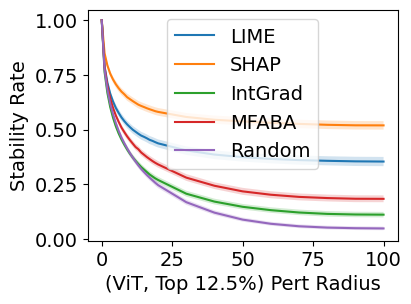

  [1/16] Saved: _dump/soft_stability_methods_vit_top_0125.pdf


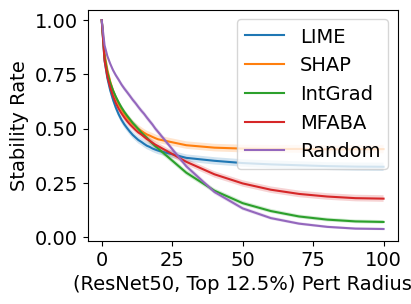

  [2/16] Saved: _dump/soft_stability_methods_resnet50_top_0125.pdf


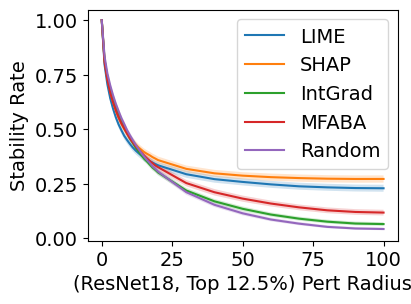

  [3/16] Saved: _dump/soft_stability_methods_resnet18_top_0125.pdf


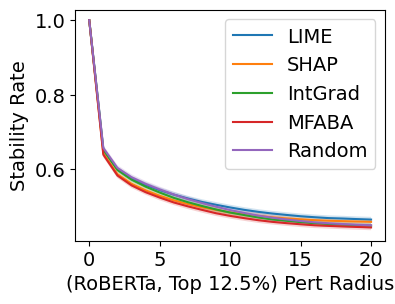

  [4/16] Saved: _dump/soft_stability_methods_roberta_top_0125.pdf

Generating plots for top-k = 0.250:


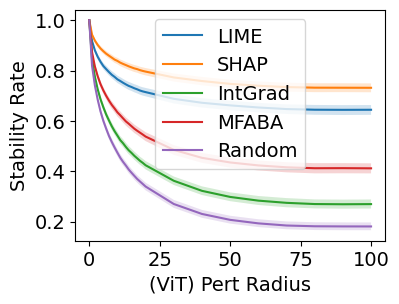

  [5/16] Saved: _dump/soft_stability_methods_vit_top_0250.pdf


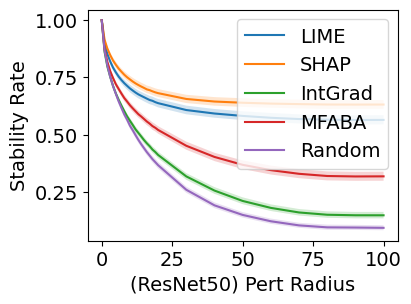

  [6/16] Saved: _dump/soft_stability_methods_resnet50_top_0250.pdf


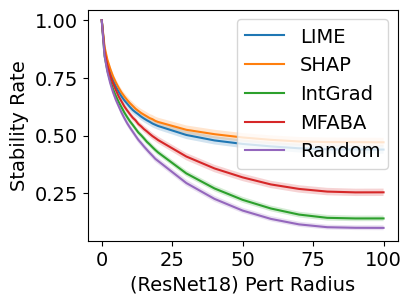

  [7/16] Saved: _dump/soft_stability_methods_resnet18_top_0250.pdf


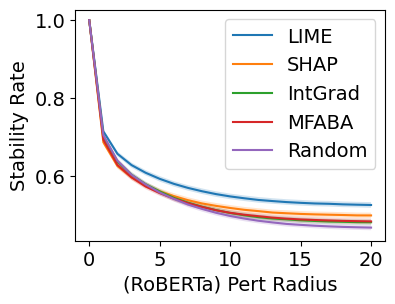

  [8/16] Saved: _dump/soft_stability_methods_roberta_top_0250.pdf

Generating plots for top-k = 0.375:


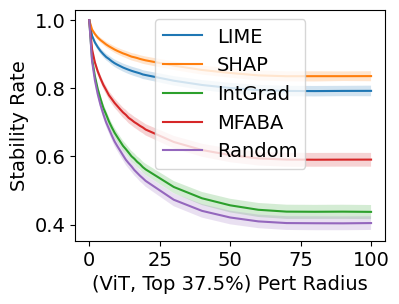

  [9/16] Saved: _dump/soft_stability_methods_vit_top_0375.pdf


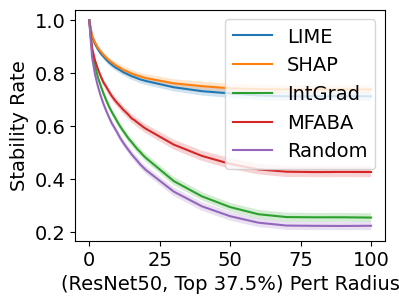

  [10/16] Saved: _dump/soft_stability_methods_resnet50_top_0375.pdf


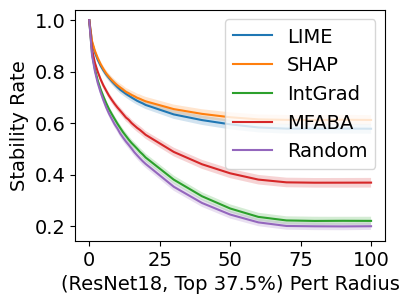

  [11/16] Saved: _dump/soft_stability_methods_resnet18_top_0375.pdf


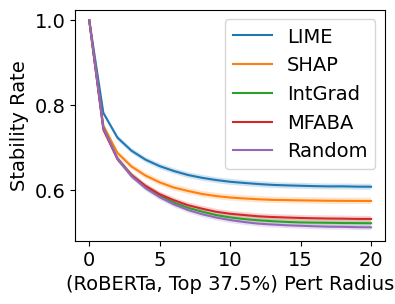

  [12/16] Saved: _dump/soft_stability_methods_roberta_top_0375.pdf

Generating plots for top-k = 0.500:


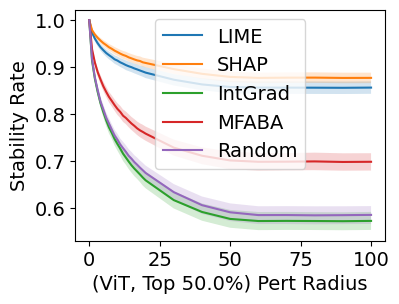

  [13/16] Saved: _dump/soft_stability_methods_vit_top_0500.pdf


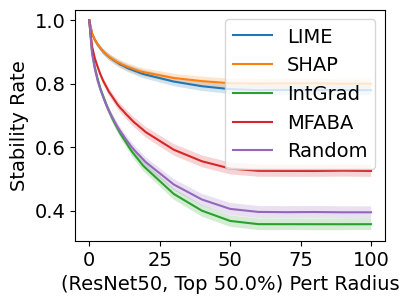

  [14/16] Saved: _dump/soft_stability_methods_resnet50_top_0500.pdf


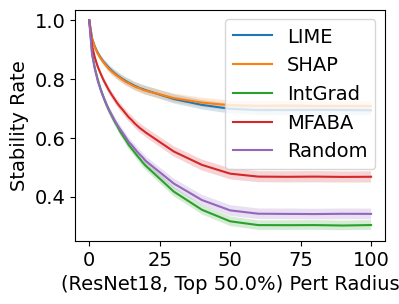

  [15/16] Saved: _dump/soft_stability_methods_resnet18_top_0500.pdf


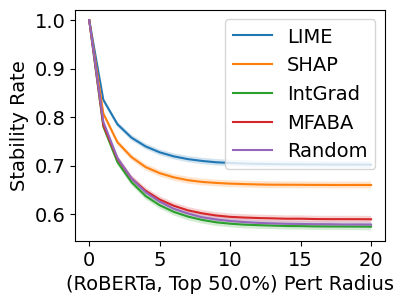

  [16/16] Saved: _dump/soft_stability_methods_roberta_top_0500.pdf

SUCCESS: Generated exactly 16 plots


In [6]:
# CRITICAL: This generates exactly 16 plots following user specification
print("Generating method comparison plots (16 total: 4 top-k × 4 models)...")
plot_count = 0

for topk_str in TOPK_VALUES:           # Loop 1: 4 top-k values
    print(f"\nGenerating plots for top-k = {topk_str}:")
    
    for model in MODELS:               # Loop 2: 4 models  
        # Determine radii based on model type
        radii = TEXT_RADII if model == "roberta" else IMAGE_RADII
        
        # Get suffix for variable names (remove dots)
        topk_suffix = topk_str.replace('.', '')
        
        # Build method_rates dictionary for this specific model+topk combination
        method_rates_dict = {}
        for method in METHODS:
            var_name = f"{model}_{method}_soft_rates_top_{topk_suffix}"
            method_rates_dict[method] = globals()[var_name]
        
        # Generate filename and plot
        output_path = f"_dump/soft_stability_methods_{model}_top_{topk_suffix}.pdf"
        
        fig = plot_methods_comparison_fixed_topk(
            model, topk_str, radii, output_path, **method_rates_dict
        )
        plt.show()
        plt.close(fig)
        plot_count += 1
        print(f"  [{plot_count}/16] Saved: {output_path}")

print(f"\nSUCCESS: Generated exactly {plot_count} plots")

## Sensitivity Analysis

Analyze how sensitive each method/model combination is to top-k selection.

In [7]:
print("Running sensitivity analysis...")
sensitivity_summary = create_sensitivity_summary()

print("\n=== TOP-K SENSITIVITY ANALYSIS ===")
print("\nAnalysis conducted at perturbation radius index 2")
print("\nResults show: Range (max-min stability), Optimal k, Current vs Optimal difference")

for model in sensitivity_summary:
    print(f"\n{model.upper()}:")
    for method in sensitivity_summary[model]:
        result = sensitivity_summary[model][method]
        print(f"  {method.upper():8s}: "
              f"Range={result['sensitivity_range']:.3f}, "
              f"Optimal k={result['optimal_topk_str']}, "
              f"Current vs Optimal={result['current_vs_optimal']:.3f}")

print("\n=== SUMMARY INSIGHTS ===")

# Find most/least sensitive methods
all_ranges = []
all_current_vs_optimal = []
method_ranges = {method: [] for method in METHODS}

for model in sensitivity_summary:
    for method in sensitivity_summary[model]:
        result = sensitivity_summary[model][method]
        all_ranges.append(result['sensitivity_range'])
        all_current_vs_optimal.append(result['current_vs_optimal'])
        method_ranges[method].append(result['sensitivity_range'])

# Method sensitivity ranking
method_avg_ranges = {method: np.mean(ranges) for method, ranges in method_ranges.items()}
sorted_methods = sorted(method_avg_ranges.items(), key=lambda x: x[1], reverse=True)

print(f"\nMethods ranked by sensitivity to top-k (most to least sensitive):")
for i, (method, avg_range) in enumerate(sorted_methods, 1):
    print(f"  {i}. {method.upper():8s}: avg range = {avg_range:.3f}")

# Overall statistics
print(f"\nOverall Statistics:")
print(f"  Average sensitivity range: {np.mean(all_ranges):.3f}")
print(f"  Max sensitivity range: {np.max(all_ranges):.3f}")
print(f"  Cases where k=0.250 is suboptimal: {sum(1 for x in all_current_vs_optimal if x < -0.001)}/{len(all_current_vs_optimal)}")
print(f"  Average improvement possible: {-np.mean([x for x in all_current_vs_optimal if x < 0]):.3f}")

print("\nSensitivity analysis complete!")

Running sensitivity analysis...

=== TOP-K SENSITIVITY ANALYSIS ===

Analysis conducted at perturbation radius index 2

Results show: Range (max-min stability), Optimal k, Current vs Optimal difference

VIT:
  LIME    : Range=0.245, Optimal k=0.500, Current vs Optimal=-0.081
  SHAP    : Range=0.176, Optimal k=0.500, Current vs Optimal=-0.051
  INTGRAD : Range=0.207, Optimal k=0.500, Current vs Optimal=-0.099
  MFABA   : Range=0.209, Optimal k=0.500, Current vs Optimal=-0.093
  RANDOM  : Range=0.195, Optimal k=0.500, Current vs Optimal=-0.137

RESNET50:
  LIME    : Range=0.205, Optimal k=0.500, Current vs Optimal=-0.086
  SHAP    : Range=0.167, Optimal k=0.500, Current vs Optimal=-0.063
  INTGRAD : Range=0.093, Optimal k=0.500, Current vs Optimal=-0.054
  MFABA   : Range=0.139, Optimal k=0.500, Current vs Optimal=-0.062
  RANDOM  : Range=0.048, Optimal k=0.500, Current vs Optimal=-0.044

RESNET18:
  LIME    : Range=0.204, Optimal k=0.500, Current vs Optimal=-0.096
  SHAP    : Range=0.17

## Create Detailed Results Table

In [8]:
print("\n=== DETAILED RESULTS TABLE ===")
print(f"{'Model':<10} {'Method':<8} {'Top 12.5%':<9} {'Top 25.0%':<9} {'Top 37.5%':<9} {'Top 50.0%':<9} {'Optimal':<8} {'Improve':<7}")
print("-" * 80)

for model in MODELS:
    for method in METHODS:
        result = sensitivity_summary[model][method]
        stab_vals = result['stability_values']
        
        print(f"{model.upper():<10} {method.upper():<8} "
              f"{stab_vals[0]:<9.3f} {stab_vals[1]:<9.3f} {stab_vals[2]:<9.3f} {stab_vals[3]:<9.3f} "
              f"{result['optimal_topk_str']:<8} {-result['current_vs_optimal']:<7.3f}")
    print()

print("Legend:")
print("  Stability values are at perturbation radius index 2")
print("  'Optimal' shows the top-k value with highest stability")
print("  'Improve' shows potential improvement over current k=0.250")


=== DETAILED RESULTS TABLE ===
Model      Method   Top 12.5% Top 25.0% Top 37.5% Top 50.0% Optimal  Improve
--------------------------------------------------------------------------------
VIT        LIME     0.716     0.880     0.935     0.961     0.500    0.081  
VIT        SHAP     0.794     0.919     0.960     0.970     0.500    0.051  
VIT        INTGRAD  0.668     0.776     0.836     0.875     0.500    0.099  
VIT        MFABA    0.701     0.817     0.876     0.910     0.500    0.093  
VIT        RANDOM   0.683     0.741     0.824     0.878     0.500    0.137  

RESNET50   LIME     0.733     0.853     0.911     0.938     0.500    0.086  
RESNET50   SHAP     0.771     0.876     0.917     0.939     0.500    0.063  
RESNET50   INTGRAD  0.759     0.798     0.829     0.852     0.500    0.054  
RESNET50   MFABA    0.740     0.818     0.850     0.880     0.500    0.062  
RESNET50   RANDOM   0.834     0.802     0.798     0.846     0.500    0.044  

RESNET18   LIME     0.706     0.814   